# Download image for using.

In [ ]:
# install gdown
!pip install gdown

In [1]:
# install image
!gdown '1M3BqiQ4DHtQkFTRzGuKHe8SV3FS_0Eu5'


Downloading...
From: https://drive.google.com/uc?id=1M3BqiQ4DHtQkFTRzGuKHe8SV3FS_0Eu5
To: /content/Dogg.jpg
100% 223k/223k [00:00<00:00, 39.6MB/s]


#Section 1 : Import libraries and read image data.

1.1) Import neccessary libraries.



In [2]:
#Answer your code here
from matplotlib import pyplot as plt
import numpy as np
import cv2
from google.colab.patches import cv2_imshow  # To display images in Google Colab
import pandas as pd
from pandas import DataFrame
!pip install summarytools
from summarytools import dfSummary
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.5 MB/s eta 0:00:00


1.2) Read image

In [3]:
#Answer your code here
dog = cv2.imread('./Dogg.jpg')

1.3) Show image

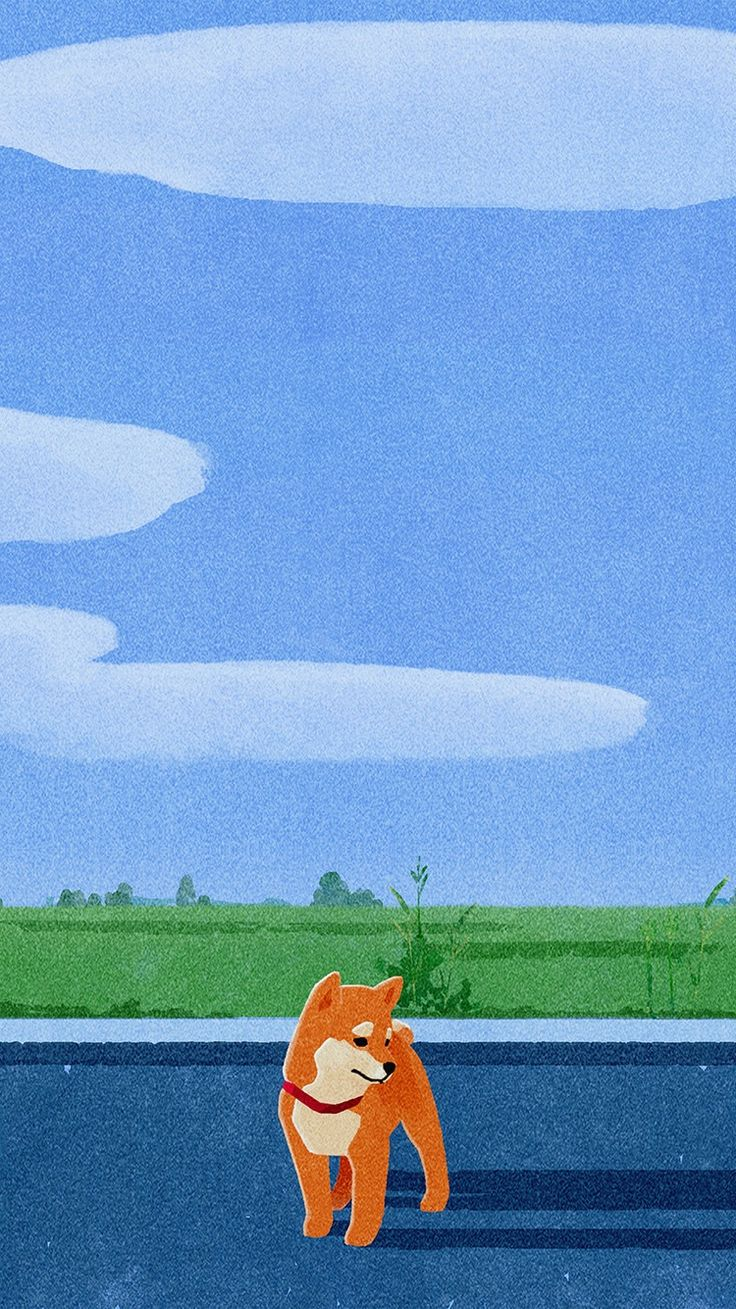

In [4]:
#Answer your code here
cv2_imshow(dog)

1.4) Read image to numpy array and show array shape.

In [5]:
#Answer your code here
image_array = np.array(dog)

print("Array Shape:", image_array.shape) #height , width ,chanels
print("Array Preview:", image_array)

Array Shape: (1309, 736, 3)
Array Preview: [[[240 165 113]
  [231 156 104]
  [234 159 107]
  ...
  [246 176 122]
  [240 170 116]
  [237 167 113]]

 [[232 157 105]
  [229 156 104]
  [228 153 101]
  ...
  [220 150  96]
  [222 152  98]
  [234 164 110]]

 [[233 160 108]
  [238 168 115]
  [232 159 107]
  ...
  [223 153  99]
  [231 161 107]
  [235 165 111]]

 ...

 [[146  94  41]
  [116  64  11]
  [136  84  31]
  ...
  [155 101  48]
  [155 101  48]
  [135  81  28]]

 [[138  86  33]
  [102  50   0]
  [118  66  13]
  ...
  [153  99  46]
  [166 112  59]
  [153  99  46]]

 [[144  92  39]
  [123  71  18]
  [121  69  16]
  ...
  [145  90  39]
  [163 108  57]
  [161 106  55]]]


# Section 2 : Convert original image to other color space and show result using matplotlib

2.1) Convert original image to YCrCb and HSV.

In [6]:
image_rgb  = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)

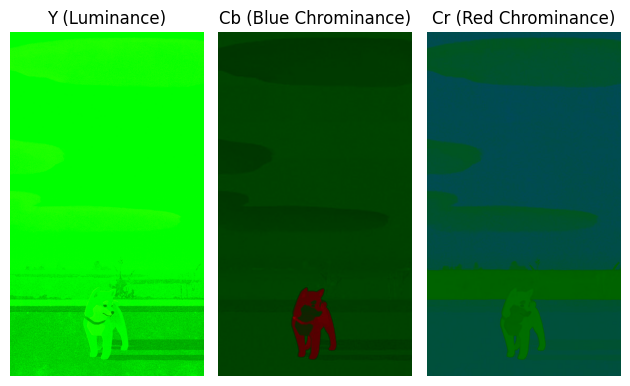

In [7]:
#Answer your code here (For show result of YCrCb)

# Convert to YCbCr color space
image_ycbcr = cv2.cvtColor(dog, cv2.COLOR_BGR2YCrCb)

# Split the channels for YCbCr
Y, Cb, Cr = image_ycbcr.copy(), image_ycbcr.copy(), image_ycbcr.copy()
Y[:,:,1]=0
Y[:,:,2]=0
Cb[:,:,0]=0
Cb[:,:,2]=0
Cr[:,:,0]=0
Cr[:,:,1]=0
Y_rgb=cv2.cvtColor(Y, cv2.COLOR_YCrCb2RGB)
Cb_rgb=cv2.cvtColor(Cb, cv2.COLOR_YCrCb2RGB)
Cr_rgb=cv2.cvtColor(Cr, cv2.COLOR_YCrCb2RGB)

# Display Y (Luminance) channel
plt.subplot(1, 3, 1)
plt.imshow(Y_rgb)
plt.title("Y (Luminance)")
plt.axis("off")

# Display Cb (Blue Chrominance) channel
plt.subplot(1, 3, 2)
plt.imshow(Cb_rgb)
plt.title("Cb (Blue Chrominance)")
plt.axis("off")

# Display Cr (Red Chrominance) channel
plt.subplot(1, 3, 3)
plt.imshow(Cr_rgb)
plt.title("Cr (Red Chrominance)")
plt.axis("off")

plt.tight_layout()
plt.show()

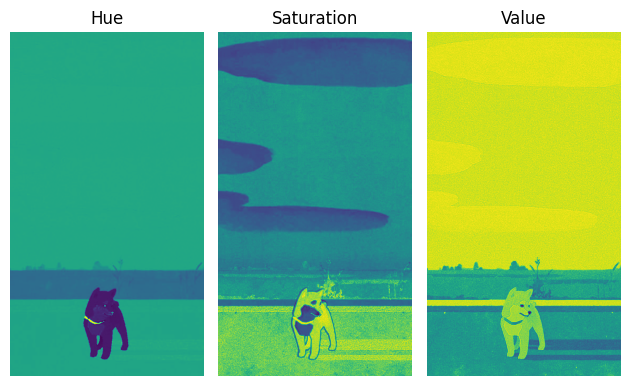

In [8]:
#Answer your code here (For show result of HSV)
image_hsv = cv2.cvtColor(dog, cv2.COLOR_BGR2HSV)

# Split the channels for hsv
h, s, v = cv2.split(image_hsv)

plt.subplot(1, 3, 1)
plt.imshow(h)
plt.title("Hue")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(s)
plt.title("Saturation")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(v)
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()


2.2) Show each channel of (2.1 result of both YCrCb and HSV) in gray using matplotlib

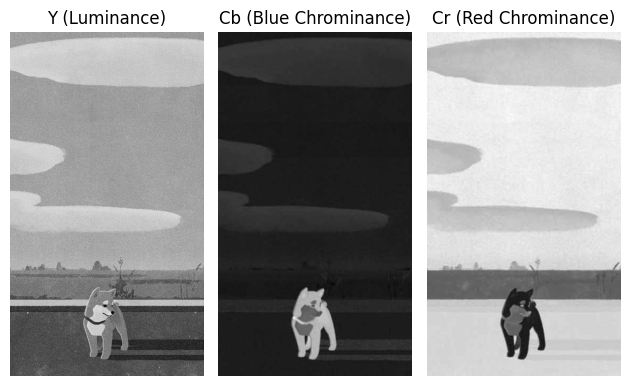

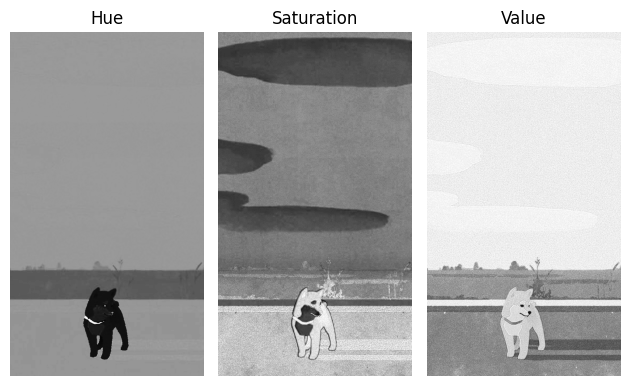

In [9]:
image_ycbcr = cv2.cvtColor(dog, cv2.COLOR_BGR2YCrCb)

# Split the channels for YCbCr
Y, Cb, Cr = cv2.split(image_ycbcr)

#Only show  Picture for each channel
# Display Y (Luminance) channel
plt.subplot(1, 3, 1)
plt.imshow(Y, cmap='gray')
plt.title("Y (Luminance)")
plt.axis("off")

# Display Cb (Blue Chrominance) channel
plt.subplot(1, 3, 2)
plt.imshow(Cb, cmap='gray')
plt.title("Cb (Blue Chrominance)")
plt.axis("off")

# Display Cr (Red Chrominance) channel
plt.subplot(1, 3, 3)
plt.imshow(Cr, cmap='gray')
plt.title("Cr (Red Chrominance)")
plt.axis("off")

plt.tight_layout()
plt.show()

image_hsv = cv2.cvtColor(dog, cv2.COLOR_BGR2HSV)

# Split the channels for hsv
h, s, v = cv2.split(image_hsv)

plt.subplot(1, 3, 1)
plt.imshow(h, cmap='gray')
plt.title("Hue")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(s, cmap='gray')
plt.title("Saturation")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(v, cmap='gray')
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()


# Section 3 : Reshape color space (YCrCb and HSV) to matrix size nx3 (2D) and show statistic values by using EDA tools.

3.1) Reshape color space (YCrCb and HSV) to matrix size nx3 (2D)

In [10]:
n = image_ycbcr.shape[0] * image_ycbcr.shape[1]
n

963424

In [11]:
#Answer your code here (For show result of YCrCb)
ycbcr_matrix = image_ycbcr.reshape((n, 3))
df_ycrcb= pd.DataFrame(ycbcr_matrix, columns=['Y', 'Cr', 'Cb'])
df_ycrcb.head(5)

,Y,Cr,Cb
0,158,96,174
1,149,96,174
2,152,96,174
3,171,96,174
4,176,96,173


In [12]:
#Answer your code here (For show result of HSV)
n = image_hsv.shape[0] * image_hsv.shape[1]
hsv_matrix = image_hsv.reshape((n, 3))
df_hsv= pd.DataFrame(hsv_matrix, columns=['H', 'S', 'V'])
df_hsv.head(5)

,H,S,V
0,108,135,240
1,108,140,231
2,108,138,234
3,108,128,253
4,107,124,255


In [15]:
from mpl_toolkits.mplot3d import Axes3D

3.2) Show plot(YCrCb and HSV) by using EDA tools.

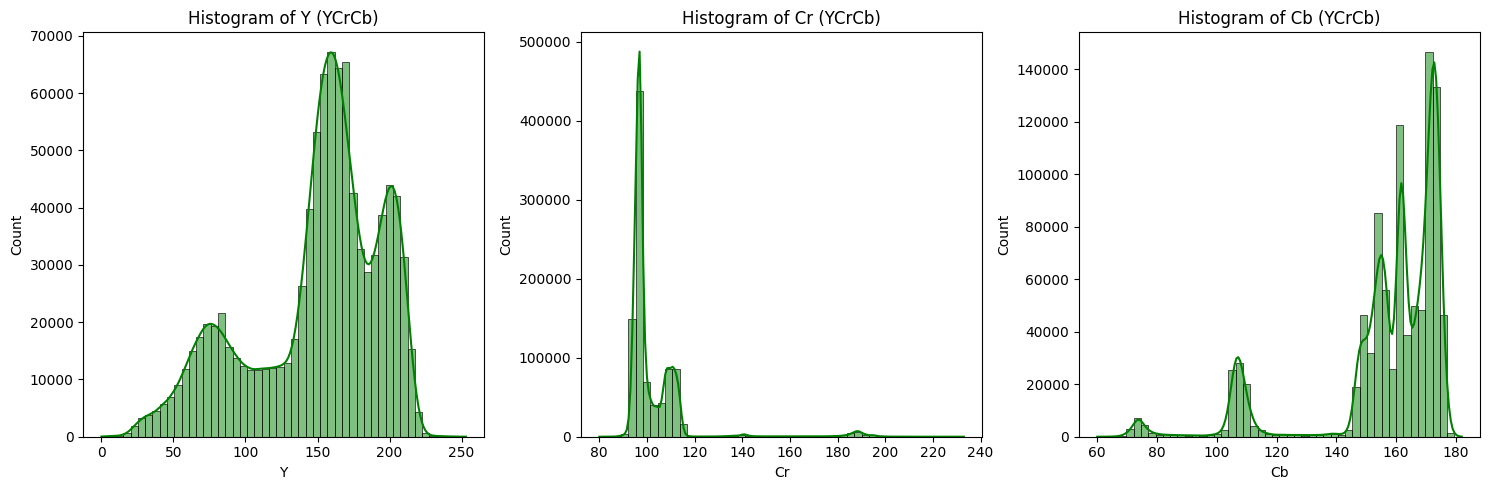

In [13]:
#Answer your code here (For show result of YCrCb)
# Don't use histogram & Boxplot
plt.figure(figsize=(15, 5))
for i, col in enumerate(['Y', 'Cr', 'Cb']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_ycrcb[col], bins=50, kde=True, color='green')
    plt.title(f"Histogram of {col} (YCrCb)")
plt.tight_layout()
plt.show()

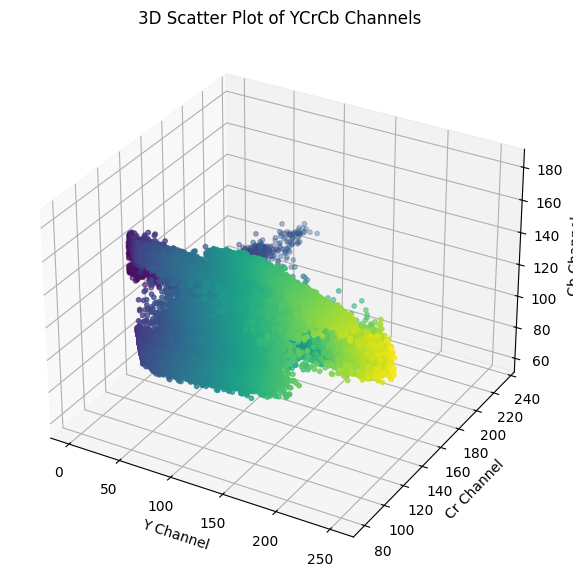

In [19]:
image_ycbcr = cv2.cvtColor(dog, cv2.COLOR_BGR2YCrCb)
n = image_ycbcr.shape[0] * image_ycbcr.shape[1]
# Reshape and create DataFrame
ycbcr_matrix = image_ycbcr.reshape((n, 3))
df_ycrcb = pd.DataFrame(ycbcr_matrix, columns=['Y', 'Cr', 'Cb'])

# 3D Scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(df_ycrcb['Y'], df_ycrcb['Cr'], df_ycrcb['Cb'], c=df_ycrcb['Y'], cmap='viridis', s=10)

# Labeling axes
ax.set_xlabel('Y Channel')
ax.set_ylabel('Cr Channel')
ax.set_zlabel('Cb Channel')
ax.set_title('3D Scatter Plot of YCrCb Channels')

plt.show()

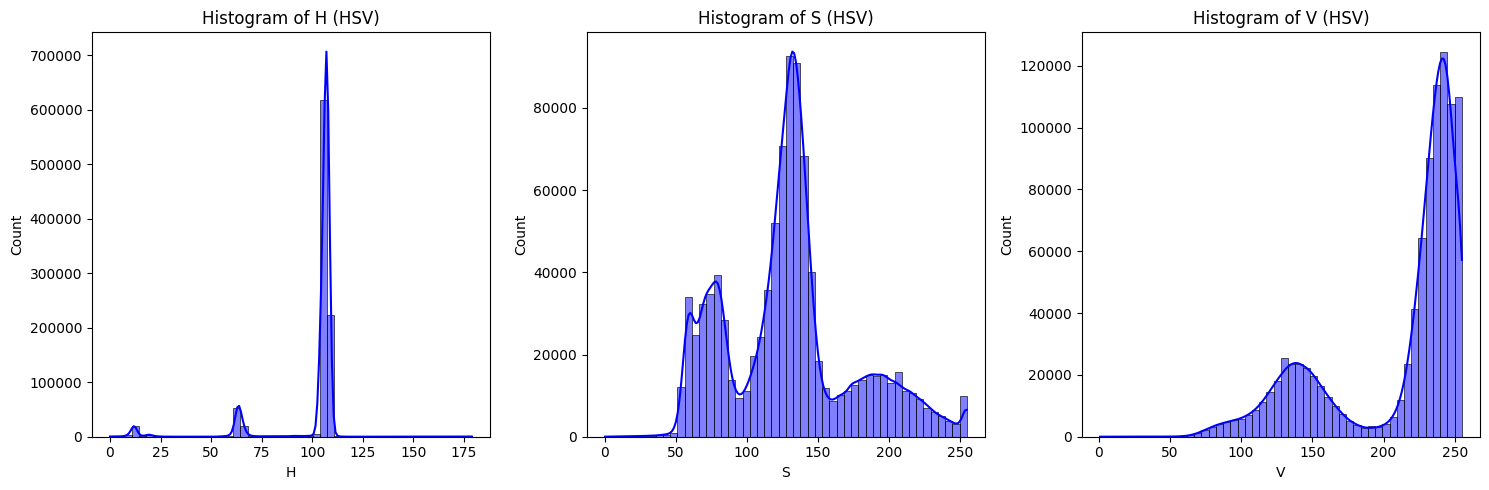

In [20]:
#Answer your code here (For show result of HSV)
plt.figure(figsize=(15, 5))
for i, col in enumerate(['H', 'S', 'V']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_hsv[col], bins=50, kde=True, color='blue')
    plt.title(f"Histogram of {col} (HSV)")
plt.tight_layout()
plt.show()



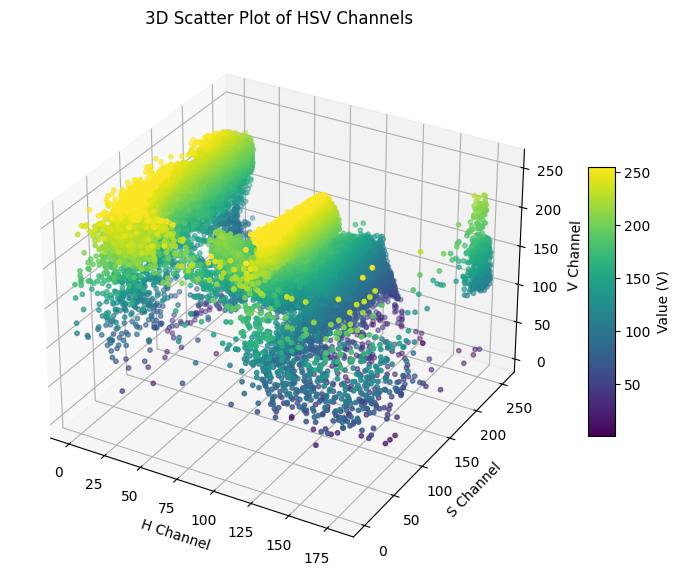

In [21]:
image_hsv = cv2.cvtColor(dog, cv2.COLOR_BGR2HSV)
# Reshape and create DataFrame
n = image_hsv.shape[0] * image_hsv.shape[1]
hsv_matrix = image_hsv.reshape((n, 3))
df_hsv = pd.DataFrame(hsv_matrix, columns=['H', 'S', 'V'])

# 3D Scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(df_hsv['H'], df_hsv['S'], df_hsv['V'], c=df_hsv['V'], cmap='viridis', s=10)

# Labeling axes
ax.set_xlabel('H Channel')
ax.set_ylabel('S Channel')
ax.set_zlabel('V Channel')
ax.set_title('3D Scatter Plot of HSV Channels')

# Add a color bar for Value (V)
cb = fig.colorbar(sc, ax=ax, shrink=0.5, aspect=10)
cb.set_label('Value (V)')

plt.show()

# Section 4 : Linear function with image

4.1) Explain definition of linear function variable 'a' and 'b' from equation 'ax + b'.



> a คือ contrast level

> b คือ brightness

4.2) If you want to adjust image to become darker than original image by using linear function, which variable should you adjust ?



> ปรับที่ค่า b ให้ลดลง



#Section 5 : Crop and save image.

5.1) Please crop image into the following  result and save in jpg

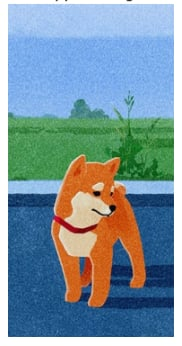

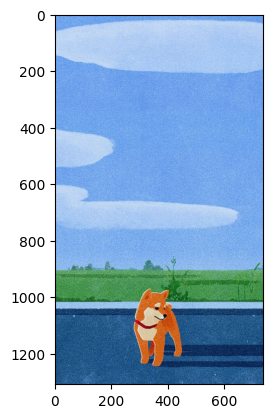

In [ ]:
plt.imshow(image_rgb)
plt.show()

In [ ]:
height, width, channels = image_rgb.shape
print(f"Height: {height}, Width: {width}, Channels: {channels}")

Height: 1309, Width: 736, Channels: 3


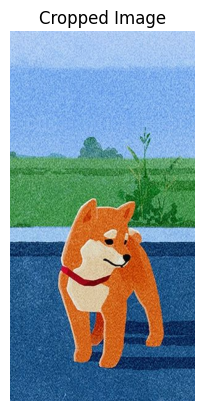

In [ ]:
# Fixed Region Crop
# Step 1: Define cropping coordinates
start_row, end_row = 700, 1300  # Define height range
start_col, end_col = 200, 500  # Define width range

# Step 2: Crop the image using NumPy slicing
cropped_image1 = image_rgb[start_row:end_row, start_col:end_col]

# Step 3: Display the cropped image
plt.imshow(cropped_image1)
plt.title("Cropped Image")
plt.axis("off")
plt.show()

In [ ]:
cropped_image_bgr = cv2.cvtColor(cropped_image1, cv2.COLOR_RGB2BGR)

# Save the cropped image in .jpg format
jpg_save_path = './cropped_image1.jpg'
cv2.imwrite(jpg_save_path, cropped_image_bgr)
print(f"File saved as JPG at: {jpg_save_path}")

File saved as JPG at: ./cropped_image1.jpg


# Section 6. Make image brighter
* read image
* convert to target color space
* apply your logic
* convert back to RGB (if need)
* show the image before and after change

## 6.1 RGB color space

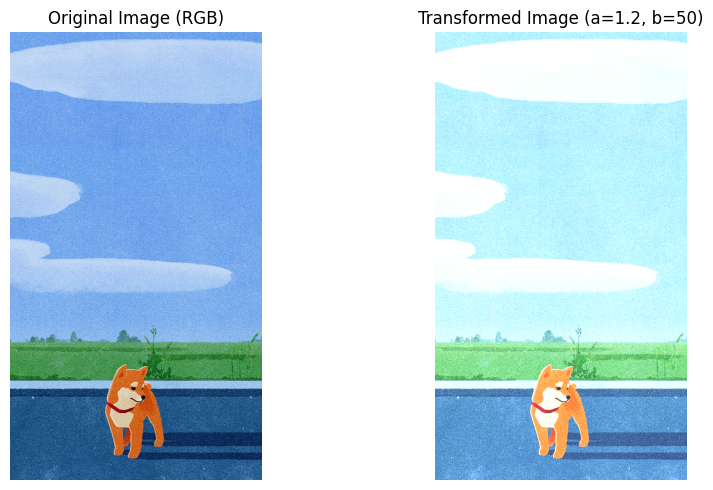

In [ ]:
#Answer your code here.
dog = cv2.imread('./Dogg.jpg')
image_rgb  = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)
# linear function: f(x)=ax+b a control complex b control brightness ??
R, G, B = cv2.split(image_rgb)

# Apply linear transformations
a = 1.2  # Multiplication constant (scaling factor) #Contrast level
b = 50   # Addition constant (offset) #Brightness

R_transformed = np.clip(a * R + b, 0, 255).astype(np.uint8)
G_transformed = np.clip(a * G + b, 0, 255).astype(np.uint8)
B_transformed = np.clip(a * B + b, 0, 255).astype(np.uint8)

# Merge the transformed channels back into an image
image_transformed = cv2.merge([R_transformed, G_transformed, B_transformed])

# Visualize original and transformed images
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image (RGB)")
plt.axis("off")

# Transformed Image
plt.subplot(1, 2, 2)
plt.imshow(image_transformed)
plt.title(f"Transformed Image (a={a}, b={b})")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6.2 HSV color space

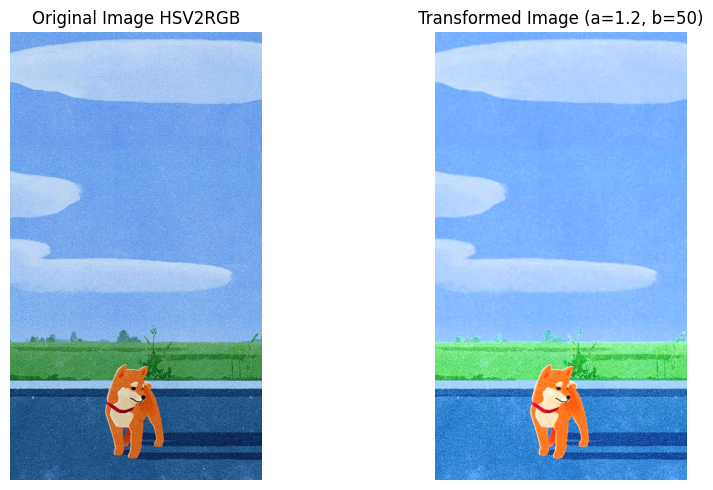

In [ ]:
#Answer your code here.
dog = cv2.imread('./Dogg.jpg')
image_hsv  = cv2.cvtColor(dog, cv2.COLOR_BGR2HSV)
# linear function: f(x)=ax+b a control complex b control brightness ??
h, s, v = cv2.split(image_hsv)

# Apply linear transformations
a = 1.2  # Multiplication constant (scaling factor) #Contrast level
b = 50   # Addition constant (offset) #Brightness

# H_transformed = np.clip(a * h + b, 0, 255).astype(np.uint8)
# S_transformed = np.clip(a * s + b, 0, 255).astype(np.uint8)
V_transformed = np.clip(a * v + b, 0, 255).astype(np.uint8)

# Merge the transformed channels back into an image
image_transformed = cv2.merge([h, s, V_transformed])

image_hsv2RGB = cv2.cvtColor(image_hsv, cv2.COLOR_HSV2RGB)
image_transformed2RGB = cv2.cvtColor(image_transformed, cv2.COLOR_HSV2RGB)

# Visualize original and transformed images
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image_hsv2RGB)
plt.title("Original Image HSV2RGB")
plt.axis("off")

# Transformed Image
plt.subplot(1, 2, 2)
plt.imshow(image_transformed2RGB)
plt.title(f"Transformed Image (a={a}, b={b})")
plt.axis("off")

plt.tight_layout()
plt.show()



# 6.3 YCbCr color space

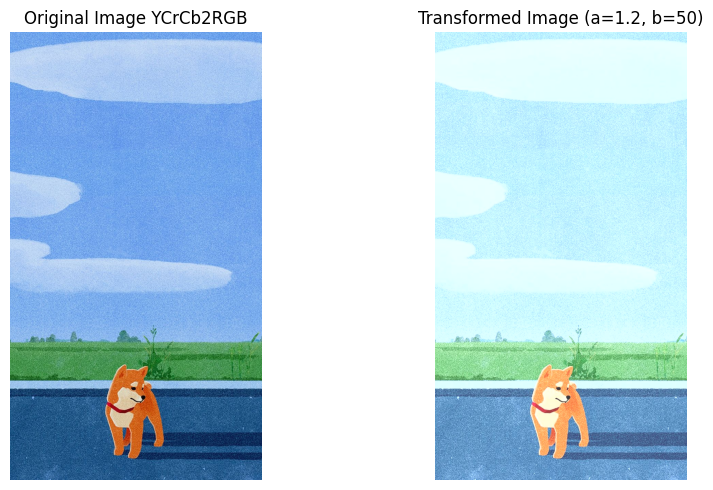

In [ ]:
#Answer your code here.
dog = cv2.imread('./Dogg.jpg')
image_ycrcb  = cv2.cvtColor(dog, cv2.COLOR_BGR2YCrCb)
# linear function: f(x)=ax+b a control complex b control brightness ??
Y, Cr, Cb = cv2.split(image_ycrcb)

# Apply linear transformations
a = 1.2  # Multiplication constant (scaling factor) #Contrast level
b = 50   # Addition constant (offset) #Brightness

Y_transformed = np.clip(a * Y + b, 0, 255).astype(np.uint8)
# Cr_transformed = np.clip(a * Cr + b, 0, 255).astype(np.uint8)
# Cb_transformed = np.clip(a * Cb + b, 0, 255).astype(np.uint8)

# Merge the transformed channels back into an image
image_transformed = cv2.merge([Y_transformed, Cr, Cb])

image_ycrcb2RGB = cv2.cvtColor(image_ycrcb, cv2.COLOR_YCrCb2RGB)
image_transformed2RGB = cv2.cvtColor(image_transformed, cv2.COLOR_YCrCb2RGB)

# Visualize original and transformed images
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image_ycrcb2RGB)
plt.title("Original Image YCrCb2RGB")
plt.axis("off")

# Transformed Image
plt.subplot(1, 2, 2)
plt.imshow(image_transformed2RGB)
plt.title(f"Transformed Image (a={a}, b={b})")
plt.axis("off")

plt.tight_layout()
plt.show()